# はじめに

このノートでは強化学習を理解するために、「ゼロから作るDeepLearning4(強化学習)」の書籍に従って、強化学習の基礎について理解を深める。ノートの中のコードは書籍のサポートページに記載されているコードを参考にさせて頂く。

- [ゼロから作るDeepLearning4(強化学習)](https://www.oreilly.co.jp/books/9784873119755/)
- [ゼロから作るDeepLearning4(強化学習)のコード](https://github.com/oreilly-japan/deep-learning-from-scratch-4/tree/master)

次の章に行く前に用語の整理をしておく。

- 価値: 報酬の期待値
- 行動価値: 行動に対して得られた報酬の期待値。QualityのQで表記
- 報酬: Rewardの$R$で表記
- 行動: Actionの$A$で表記
- 状態: Stateの$S$で表記
- 状態遷移確率: $p(s^{'}|s,a)$
- 報酬関数: $r(s,a,s^{'})$
- 方策: $\pi(a|s)$
- 収益: Returnではあるが$G$で表記される


## 第2章: マルコフ決定過程

スロットマシンでは、エージェントがアクションして最善のスロットマシンを探索するものの、実際は行動すると状況が変わることのほうが多い。これらの問題を扱う考え方として、マルコフ決定過程(Markov decision process; MDP)がある。

マルコフ決定過程は、エージェントが環境と相互作用しながら行動を決定する過程のこと。下記のグリッドワールドを考える。エージェントは左右に移動でき、グリッドごとに報酬が定められている。

|+1|0|0|0|-1|
|:--:|:--:|:--:|:--:|:--:|
|Apple|Space| Agent | Space| Bomb|
||| ←→ | | |

エージェントは「左に移動して、左に移動すれば報酬が+1」もらえる一方で、「右に移動して、右に移動すれば報酬が-1される。このようにエージェントが行動としてグリッドを移動すれば、エージェントが置かれている状況が変わる。強化学習では、これを「状態(State)」と呼ぶ。つまり、エージェントの行動で状況が変わり、状態が遷移した先で新たな行動を行う。ここでまた別のグリッドワールドを考える。

|+1|0|0|-2|+6|
|:--:|:--:|:--:|:--:|:--:|
|Apple|Space| Agent | Bomb| Apple|
||| ←→ | | |

このグリッドワールドでは、マイナスの報酬が発生するものの、右に2つ進むことが最適な行動であり、総和が最大になる。
エージェントと環境のやり取りはフロー図で表現される。ネットで検索するとたくさん出てくるので画像は載せていないが、ある時刻$t$において状態$S_{t}$を想定すると、エージェントが行動$A_{t}$を行うことで、報酬$R_{t}$を得る。そして、次の状態$S_{t+1}$へと遷移する。これが繰り返されることで学習する。

$$
\begin{aligned}
S_{0}, A_{0}, R_{0}, S_{1}, A_{1}, R_{1}, S_{2}, A_{2}, R_{2},... 
\end{aligned}
$$

環境とエージェントの相互のやりとりは、状態遷移、報酬、方策の3つの要素によって定式化される。

- 状態遷移: 状態がどのように遷移するのか 
- 報酬: 報酬はどのように与えられるのか
- 方策: エージェントはどのように行動を決定するのか

## 状態遷移
状態遷移には、決定論的か確率論的かに分類される。決定論的な場合、次の状態$s^{'}$は今の状態と行動によって決定される。状態遷移関数として$s^{'}=f(s,a)$で表現される。一方で確率的な場合、状態遷移確率として$p(s^{'}|s,a)$で表現される。

|      |  L1  |  L2  |  L3   |  L4  |  L5  |
|:----:|:----:|:----:|:-----:|:----:|:----:|
| GRID |Space |Space |Agent  |Space |Space |
|      |      |      |  ←    |      |      |
| $s'$           | L1  | L2  | L3  | L4 | L5 |
| $p(s' \mid s,a)$  |  0  | 0.9 | 0.1 | 0  | 0  |

$L3$にエージェントがいて、行動としてLEFTを選択する場合、状態遷移確率は$p(s^{'}|s=L3,a=LEFT)$として表現される。見て分かる通り、$p(s^{'}|s,a)$は現在の状態$s$と行動$a$にのみ依存して、次の状態$s^{'}$が決まる。この性質をマルコフ性と呼ぶ。

## 報酬関数
現在の状態$s$において、行動$a$を行い、次の状態$s^{'}$になったときの報酬を$r(s,a,s^{'})$として、報酬関数と呼ぶ。例えばL1にりんごがあったとき、エージェントはL2にいるとする、L1に動いたとき$r(s=L2, a=LEFT, s^{'}=L1)=1$として報酬が得られる。

## エージェントの方策
エージェントの方策とは、エージェントがどのように動くかのルールを定めるもの。マルコフ性により、現在の状態$s$と行動$a$という現在の状態に基づいて行動を決定する。行動の決め方は、決定論的か確率論的かにわけられる。決定論であっても、0か1で考えれば確率論的ともいえるが、ここではこれは決定論的として扱う。

| |  L1  |  L2  |  L3   |  L4  |  L5  |
|:----:|:----:|:----:|:-----:|:----:|:----:|
| |Space |Space |Agent  |Space |Space |
|決定論 |      | LEFT=1 |  ←・   | RIGHT=0 |      |
|確率論 |   | LEFT=0.4  | ←・→  | RIGHT=0.6 |  |

方策関数として$a = \mu(s)$のように定義される。エージェントがある場所にいて、必ず左に移動する行動を取るのであれば、
$$
a = \mu(s=L3) → LEFT
$$

となる。一方で確率的な方策の場合、$\pi(a|s)$として定義される。左に移動する確率が0.6、右に移動する確率が0.4であるため、$\pi(a|s)$はある状態$s$にいるときに行動$a$を取る確率を表す。

$$
\begin{aligned}
\pi(a&=LEFT|s=L3) = 0.4 \\
\pi(a&=RIGHT|s=L3) = 0.6 \\
\end{aligned}
$$

## マルコフ決定過程の目標

エージェントは方策$\pi(a|s)$によって行動する。つまり、ある状態にいるという条件のもとでの、次の行動を確率的に考える。その行動は状態遷移確率$p(s^{'}|a, s)$によって確率的に次の状態に遷移する。そして、報酬関数$r(s,a,s^{'})$によって、報酬が与えられる。この枠組みにおいて、エージェントが最適方策(収益が最大化する)を見つけることがマルコフ決定過程の目的。最適方策には「エピソードタスク」「連続タスク」の2つの考え方が存在する。

エピソードタスクは「終りが存在する」問題のことで、連続タスクは「終わりがない」問題のこと。これまで例として使っているグリッドワールドもエピソードタスクである。ある場所に報酬がもらえるゴールがあり、そのゴールに達すると初期状態から再スタートする。一方で終わりのない問題は、強化学習エージェントに在庫管理を任せる問題は終わりのない連続タスクである。エージェントは売れ行きや在庫の量を判断して、どれくらい仕入れるかどうかを決定しないといけない。

ここで収益$G$いう概念も導入する、エージェントの目的はこの収益を最大化すること。時刻$t$で状態$S_{t}$である場合において、方策$\pi$によって、行動$A_{t}$を行い、報酬$R_{t}$を得て、新しい状態$S_{t+1}$に遷移する。このとき収益$G_{t}$は下記のように定義される。$\gamma$は割引率(0-1)。割引率がないと収束せずに発散してしまう。

$$
\begin{aligned}
G_{t} &= R_{t} + \gamma R_{t+1} + \gamma R_{t+2} + ... \\
&= \sum_{k=0}^{\infty} \gamma^{k} R_{t+k}
\end{aligned}
$$

収益はエージェントが得る報酬の和として定義される。ここでの注意点は、エージェントも環境も確率的に振る舞う。そのため、収益も確率的に振る舞うことになる。そのため、収益の期待値が必要になる。

$$
\begin{aligned}
\nu_{\pi}(s) = \mathbb{E}_{\pi}[G_{t}|S_{t}=s] 
\end{aligned}
$$

状態とエージェントの方策($\mathbb{E}$の下付き${\pi}$)を条件とした収益の期待値として定義される。そして、最適方策を探すためには、最適を定義する必要がある。例えば2つの方策があったとき、どちらが最適か。ある時点では$\nu_{pi'} > \nu_{pi}$であり、またある時点では$\nu_{pi'} < \nu_{pi}$。このため、この2つの方策のどちらが最適かを判断できない。判断できる場合は右の図のように常に優劣が一定である必要がある。

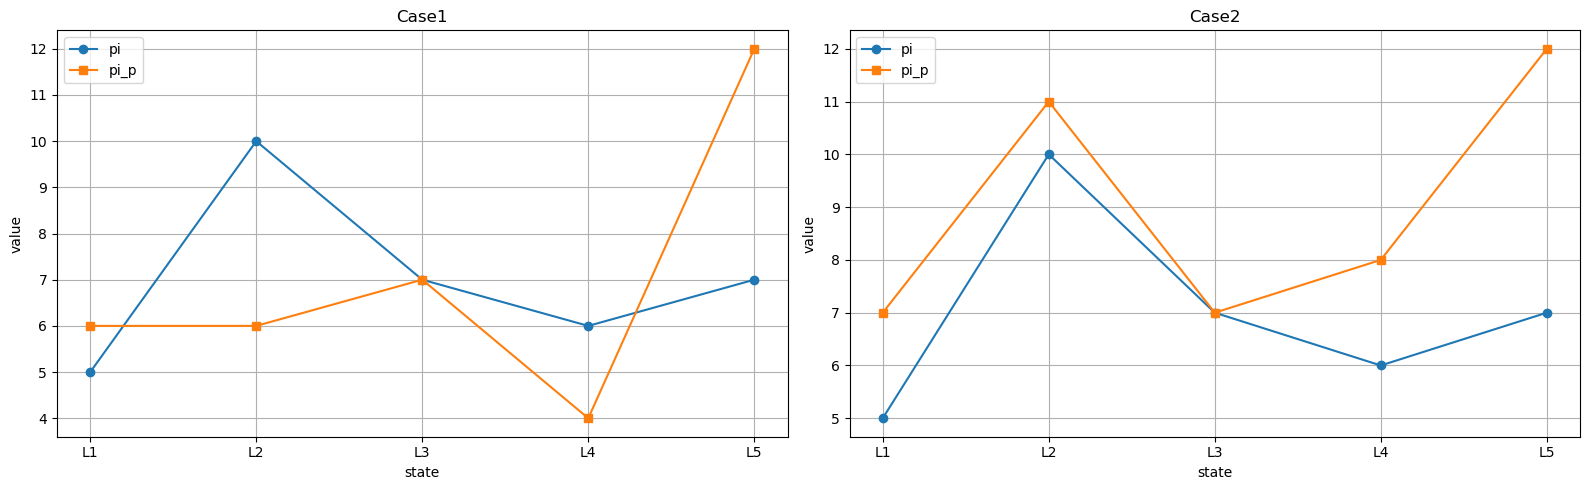

In [11]:
import matplotlib.pyplot as plt

state = ['L1', 'L2', 'L3', 'L4', 'L5']

# 1つ目のデータ
pi1 = [5,10,7,6,7]
pi_p1 = [6,6,7,4,12]

# 2つ目のデータ
pi2 = [5,10,7,6,7]
pi_p2 = [7,11,7,8,12]

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# 左側のグラフ
axes[0].plot(state, pi1, marker='o', label='pi')
axes[0].plot(state, pi_p1, marker='s', label='pi_p')
axes[0].set_xlabel('state')
axes[0].set_ylabel('value')
axes[0].legend()
axes[0].grid(True)
axes[0].set_title('Case1')

# 右側のグラフ
axes[1].plot(state, pi2, marker='o', label='pi')
axes[1].plot(state, pi_p2, marker='s', label='pi_p')
axes[1].set_xlabel('state')
axes[1].set_ylabel('value')
axes[1].legend()
axes[1].grid(True)
axes[1].set_title('Case2')

plt.tight_layout()
plt.show()


実際に連続タスクのグリッドワールドを例に考える。L1とL2の2マス存在しており、エージェントはL1にいて、L2のりんごを取得すると報酬＋１がもらえる。壁にぶつかると報酬は-1される。言い換えると、L1にいて、LEFTを選択すると壁にぶつかる。L2にいて、RIGHTを選択すると壁にぶつかる。L2からL1に移動すると、りんごが再出現する。エージェントは左右のどちらに移動でき、状態遷移は決定論的にあつかう。各状態における状態価値を状態価値関数をもとに計算してみる。これをまとめると方策のパターンを整理できる。

|     |$s=L1$ |$s=L2$ |
|:---:|:---:|:---:|
|$\mu_{1}(s)$|RIGHT|RIGHT|
|$\mu_{2}(s)$|RIGHT|LEFT|
|$\mu_{3}(s)$|LEFT|RIGHT|
|$\mu_{4}(s)$|LEFT|LEFT|

- $\mu_{1}(s)$の初期状態が$L1$ではRIGHTの行動を行い、状態が$L2$ではRIGHTの行動を行う。L1に戻ることはない。
- $\mu_{1}(s)$の初期状態が$L2$ではRIGHTの行動を行い、状態が$L2$ではRIGHTの行動を行う。L1に戻ることはない。
- $\mu_{2}(s)$の初期状態が$L1$ではRIGHTの行動を行い、状態が$L2$ではLEFTの行動を行う。
- $\mu_{2}(s)$の初期状態が$L2$ではLEFTの行動を行い、状態が$L1$ではLEFTの行動を行う。L2に戻ることはない。

例えば、$\mu_{1}(s=L1)$の状態価値は下記の状態価値関数の通り計算できる。

$$
\begin{aligned}
\nu_{\mu_{1}}(s=L1) &= \mathbb{E}_{\mu_{1}} \left[ \sum_{t=0}^{\infty} \gamma^{t} R_{t} | S_{t} = L1 \right] \\
&= 1 + 0.9(-1) + 0.9^{2}(-1) + ... \\
&= -8
\end{aligned}
$$

無限等比級の和がでてくるので、公式を利用すると下記の通り計算できる。

$$
\begin{aligned}
\nu_{\mu_{1}}(s=L1) &= \mathbb{E}_{\mu_{1}} \left[ \sum_{t=0}^{\infty} \gamma^{t} R_{t} | S_{t} = L1 \right] \\
&= 1 + \gamma(-1) + \gamma^{2}(-1) + \gamma^{3}(-1) + ... \\
&= 1 - \gamma - \gamma^{2} - \gamma^{3}- ... \\
&= 1 - \gamma(1+\gamma+\gamma^2+\gamma^{3}+...)\\
&= 1 - \gamma \left( \frac{1}{1-\gamma} \right) \\
&= \frac{1-2\gamma}{1-\gamma}
\end{aligned}
$$

$\mu_{1}(s=L2)$の状態価値は下記の状態価値関数の通り計算できる。

$$
\begin{aligned}
\nu_{\mu_{1}}(s=L2) &= \mathbb{E}_{\mu_{1}} \left[ \sum_{t=0}^{\infty} \gamma^{t} R_{t} | S_{t} = L2 \right] \\
&= -1 + \gamma(-1) + \gamma^{2}(-1) + \gamma^{3}(-1) + ... \\
&= -1 - \gamma - \gamma^{2} - \gamma^{3}- ... \\
&= -1 - \gamma(1+\gamma+\gamma^2+\gamma^{3}-...)\\
&= -1 - \gamma \left( \frac{1}{1-\gamma} \right) \\
&= -\frac{1}{1-\gamma}
\end{aligned}
$$

$\mu_{2}(s=L1)$の状態価値も同様である。

$$
\begin{aligned}
\nu_{\mu_{2}}(s=L1) &= \mathbb{E}_{\mu_{2}} \left[ \sum_{t=0}^{\infty} \gamma^{t} R_{t} | S_{t} = L1 \right] \\
&= 1 + \gamma(0) + \gamma^{2}(1) + \gamma^{3}(0) + \gamma^{4}(1)... \\
&= 1 + \gamma^{2} + \gamma^{4} + ... \\
&= 1 + \gamma^{2}(1+\gamma^{2}+...)\\
&= 1 + \gamma^{2} \left( \frac{1}{1-\gamma^{2}} \right) \\
&= \frac{1}{1-\gamma^{2}}
\end{aligned}
$$

これをまとめると、$\mu_{2}(s)$が優れた方策であることがわかる。つまり、$\mu_{2}(s)$は最適方策である。

|     |$s=L1$ |$s=L2$ |
|:---:|:---:|:---:|
|$\mu_{1}(s)$|$\frac{1-2\gamma}{1-\gamma}=-8$|$-\frac{1}{1-\gamma}=-10$|
|$\mu_{2}(s)$|$\frac{1}{1-\gamma^{2}}=5.26$|$\frac{\gamma}{1-\gamma^{2}}=4.73$|
|$\mu_{3}(s)$|$-\frac{1}{1-\gamma}=-10$|$-\frac{1}{1-\gamma}=-10$|
|$\mu_{4}(s)$|$-\frac{1}{1-\gamma}=-10$|$-\frac{\gamma}{1-\gamma}=-9$|

ただ、実際の問題では２マスのグリッドワールドのように簡単な問題ではないため、ベルマン方程式を利用して対応する。